# Part 5: Model Comparison and Error Analysis

**Owners:** whole group (plan steps 44 to 51); assembled by Serein Byiringiro Shima

This notebook trains nothing. It reads the validation predictions that notebooks 01 to 04 saved for the five approaches, TF-IDF + Ridge, TF-IDF + SVR, Simple RNN, LSTM and GRU, and compares them on exactly the same 1,999 validation tweets. It asks three questions:

1. How do the five approaches compare, and how much of the difference could be chance? (sections 3 and 4)
2. Where do they differ: which kinds of tweets does each handle better or worse? (section 5)
3. Which tweets are hard for every model, and why? (section 6)

| Output | Path |
|---|---|
| Comparison table | `results/model_comparison.csv` |
| Figures | `results/figures/comparison_*.png` |
| Combined experiment log | `results/experiment_results.csv` (rebuilt in section 7) |

Tweet text is never written to a file; only small samples are printed, because the challenge rules do not allow the tweets to be published (Zindi, 2020).

## 1. Setup

In [1]:
# Setup: works on Google Colab and locally.
import subprocess
import sys
from pathlib import Path

REPO = "vaccine-sentiment-sequential-models"
if "google.colab" in sys.modules:
    ROOT = Path("/content") / REPO
    if not ROOT.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/Adossi-design/{REPO}.git", str(ROOT)], check=True)
    else:  # already cloned: pull the latest commits
        subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(ROOT / "requirements.txt")], check=True)
else:
    ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "common.py").exists())
sys.path.insert(0, str(ROOT))

from src import common

common.print_environment()

Python 3.13.15
numpy 2.5.3
pandas 3.0.6
scikit-learn 1.9.1
tensorflow 2.21.0
keras 3.15.1
GPU none


In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve

from src.evaluate import mae
from src.preprocess import prepare_series

MODELS = {"ridge": "TF-IDF + Ridge", "svr": "TF-IDF + SVR", "rnn": "Simple RNN", "lstm": "LSTM", "gru": "GRU"}
FAMILY = {"ridge": "TF-IDF baseline", "svr": "TF-IDF baseline",
          "rnn": "recurrent", "lstm": "recurrent", "gru": "recurrent"}
NEGATION = r"\b(?:not|no|never|nor|cannot)\b|n't"  # the negation pattern notebooks 03 and 04 use
common.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Figure style shared with notebook 04: thin marks, a recessive grid, text in ink colours.
INK, INK_2, GRID, GRAY = "#0b0b0b", "#52514e", "#e4e3df", "#8a8984"
BLUE = "#2a78d6"
SERIES = {"ridge": "#2a78d6", "svr": "#eb6834", "rnn": "#1baf7a", "lstm": "#eda100", "gru": "#e87ba4"}  # fixed order
SEQUENTIAL = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2, "savefig.dpi": 200, "savefig.bbox": "tight",
})

## 2. Load the five prediction files (step 44)

Each model notebook saved `results/<model>_validation_predictions.csv` with the columns `tweet_id`, `true_label` and `predicted_label`. The cell below checks that every file covers exactly the shared validation tweets and carries the same true labels as the shared split, then lines the five sets of predictions up tweet by tweet, so every comparison in this notebook is on identical tweets.

In [3]:
train_df, val_df = common.load_train_validation()
y = val_df["label"].to_numpy(dtype=float)

preds = {}
for key, name in MODELS.items():
    path = common.RESULTS_DIR / f"{key}_validation_predictions.csv"
    file = pd.read_csv(path, dtype={"tweet_id": str})
    if len(file) != len(val_df) or set(file["tweet_id"]) != set(val_df["tweet_id"]):
        raise ValueError(f"{path.name} does not cover exactly the shared validation tweets")
    file = file.set_index("tweet_id").loc[val_df["tweet_id"]]
    if not np.array_equal(file["true_label"].to_numpy(dtype=float), y):
        raise ValueError(f"{path.name} has true labels that differ from the shared split")
    preds[key] = file["predicted_label"].to_numpy(dtype=float)
P = pd.DataFrame(preds, index=val_df["tweet_id"])

CONSTANT_RMSE = common.rmse(y, np.full_like(y, train_df["label"].mean()))
print(f"{len(P):,} validation tweets, {len(MODELS)} approaches; all files checked")
print(f"Always predicting the training mean gives validation RMSE {CONSTANT_RMSE:.4f}")

1,999 validation tweets, 5 approaches; all files checked
Always predicting the training mean gives validation RMSE 0.6459


## 3. One comparison table (step 45)

**Metrics.** RMSE is the challenge metric and the group's main one; it squares each error, so a negative tweet predicted as positive (error 2) costs four times as much as one predicted as neutral (Chai & Draxler, 2014). MAE is reported beside it because it weighs all errors equally (Willmott & Matsuura, 2005).

**Uncertainty.** A single validation set of 1,999 tweets gives one number per model, so the table adds a 95% interval from a paired bootstrap: the validation tweets are resampled with replacement 2,000 times and every model is scored on the same resample (Koehn, 2004; Dror et al., 2018). The last column gives the share of resamples in which a model beats the best one; values far from 0 mean the ranking could flip with a different sample of tweets.

**Clipping.** Labels lie between -1 and 1, but the models output any number. Clipping a prediction to [-1, 1] can only move it closer to the true label, so it can only lower the error. The saved predictions are unclipped; the table shows the clipped RMSE for all five with the same rule, so the decision is applied equally.

**Seeds.** The recurrent models start from random weights, so their owners retrained the final configuration with several seeds. The seed mean and standard deviation come from the experiment logs (Reimers & Gurevych, 2017). The TF-IDF models are deterministic.

In [4]:
logs = common.merge_experiment_logs()  # rebuilds results/experiment_results.csv from every model's log
logs["val_rmse"] = logs["val_rmse"].astype(float)

# The final configuration's runs with different seeds, as notebooks 02 to 04 report them
# (notebook 03's lstm-final repeats lstm-01's seed 42, so it is not counted twice).
FINAL_SEED_RUNS = {
    "rnn": ["rnn-04", "rnn-15", "rnn-16"],
    "lstm": ["lstm-01", "lstm-01-seed43", "lstm-01-seed44", "lstm-final-seed7", "lstm-final-seed123", "lstm-final-seed2026"],
    "gru": ["gru-09", "gru-15", "gru-16"],
}

rng = np.random.default_rng(common.SEED)
BOOT = rng.integers(0, len(y), size=(2000, len(y)))  # the same 2,000 resamples for every model


def boot_rmse(pred):
    return np.sqrt(((pred[BOOT] - y[BOOT]) ** 2).mean(axis=1))


boot = {k: boot_rmse(P[k].to_numpy()) for k in MODELS}
BEST = min(MODELS, key=lambda k: common.rmse(y, P[k]))

rows = []
for key, name in MODELS.items():
    pred = P[key].to_numpy()
    seeds = logs.set_index("run_id").loc[FINAL_SEED_RUNS[key], "val_rmse"] if key in FINAL_SEED_RUNS else None
    low, high = np.percentile(boot[key], [2.5, 97.5])
    rows.append({
        "approach": name, "family": FAMILY[key],
        "owner": logs.loc[logs["model"] == key, "owner"].iloc[0],
        "runs logged": int((logs["model"] == key).sum()),
        "val RMSE": common.rmse(y, pred),
        "95% interval": f"{low:.3f} to {high:.3f}",
        "RMSE clipped": common.rmse(y, np.clip(pred, -1, 1)),
        "MAE": mae(y, pred),
        "seed mean": seeds.mean() if seeds is not None else np.nan,
        "seed sd": seeds.std() if seeds is not None else 0.0,
        "seeds": len(seeds) if seeds is not None else 1,
        f"beats {MODELS[BEST]} in": np.mean(boot[key] < boot[BEST]) if key != BEST else np.nan,
    })
comparison = pd.DataFrame(rows, index=list(MODELS)).sort_values("val RMSE")
with pd.option_context("display.float_format", "{:.4f}".format):
    display(comparison.drop(columns="owner"))
print(f"Constant prediction: {CONSTANT_RMSE:.4f}. Lowest RMSE: {MODELS[BEST]}.")

wins = pd.DataFrame({MODELS[b]: {MODELS[a]: np.mean(boot[a] < boot[b]) for a in comparison.index}
                     for b in comparison.index})
print("Share of the 2,000 paired resamples in which the row approach has a lower RMSE than the column approach:")
display(wins.round(3))

,approach,family,runs logged,val RMSE,95% interval,RMSE clipped,MAE,seed mean,seed sd,seeds,beats TF-IDF + Ridge in
ridge,TF-IDF + Ridge,TF-IDF baseline,7,0.5628,0.542 to 0.583,0.5607,0.4213,NaN,0.0000,1,NaN
svr,TF-IDF + SVR,TF-IDF baseline,8,0.5740,0.555 to 0.593,0.5730,0.4626,NaN,0.0000,1,0.0000
gru,GRU,recurrent,15,0.5769,0.557 to 0.596,0.5763,0.4436,0.5762,0.0028,3,0.0020
lstm,LSTM,recurrent,13,0.5780,0.556 to 0.599,0.5774,0.4337,0.5776,0.0060,6,0.0010
rnn,Simple RNN,recurrent,15,0.5855,0.564 to 0.606,0.5854,0.4458,0.5876,0.0021,3,0.0000


Constant prediction: 0.6459. Lowest RMSE: TF-IDF + Ridge.
Share of the 2,000 paired resamples in which the row approach has a lower RMSE than the column approach:


,TF-IDF + Ridge,TF-IDF + SVR,GRU,LSTM,Simple RNN
TF-IDF + Ridge,0.000,1.000,0.998,0.999,1.000
TF-IDF + SVR,0.000,0.000,0.700,0.754,0.973
GRU,0.002,0.300,0.000,0.656,0.981
LSTM,0.001,0.246,0.344,0.000,0.994
Simple RNN,0.000,0.027,0.019,0.006,0.000


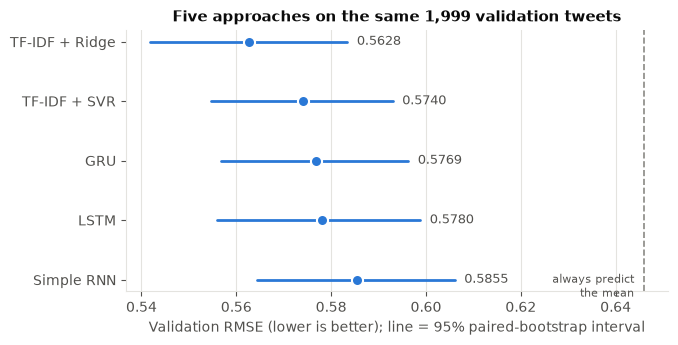

In [5]:
order = comparison.index[::-1]  # best at the top
ypos = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7, 3.4))
for i, key in enumerate(order):
    low, high = np.percentile(boot[key], [2.5, 97.5])
    ax.plot([low, high], [i, i], color=BLUE, linewidth=2, solid_capstyle="round")
    ax.scatter(comparison.loc[key, "val RMSE"], i, color=BLUE, s=64, zorder=3, edgecolors="white", linewidths=1.5)
    ax.text(high + 0.002, i, f"{comparison.loc[key, 'val RMSE']:.4f}", va="center", color=INK_2, fontsize=9)
ax.axvline(CONSTANT_RMSE, color=GRAY, linestyle="--", linewidth=1.2)
ax.text(CONSTANT_RMSE - 0.002, -0.35, "always predict\nthe mean", ha="right", va="bottom", color=INK_2, fontsize=8)
ax.set_yticks(ypos, [MODELS[k] for k in order])
ax.grid(axis="y", visible=False)
ax.set(xlabel="Validation RMSE (lower is better); line = 95% paired-bootstrap interval",
       title="Five approaches on the same 1,999 validation tweets")
fig.savefig(common.FIGURES_DIR / "comparison_rmse.png")
plt.show()

**Reading the comparison.**

- TF-IDF + Ridge has the lowest RMSE (0.5628) and beats every other approach in at least 99.8% of the paired resamples. The 95% intervals overlap widely, but most of that width comes from which tweets happen to be sampled, which moves all five models together; comparing them on the same resample removes it.
- The three recurrent models sit between 0.5769 and 0.5855. The GRU and LSTM beat the Simple RNN in 98.1% and 99.4% of resamples, so gating helps. The GRU beats the LSTM in only 65.6%, close to a coin flip, and SVR against the GRU (70.0%) is similarly unsettled.
- MAE ranks the models differently. SVR has the second-lowest RMSE but the highest MAE (0.4626), while the LSTM has the second-lowest MAE (0.4337). SVR makes many small errors and few very large ones, which suits RMSE; notebook 01 saw the same trade when a wider epsilon lowered RMSE and raised MAE.
- Clipping to [-1, 1] lowers every RMSE a little, most for Ridge (0.5628 to 0.5607), and changes no ranking.
- The LSTM's six seeds spread more (sd 0.0060) than the GRU's or Simple RNN's three (0.0028 and 0.0021). The seed means (GRU 0.5762, LSTM 0.5776, Simple RNN 0.5876) keep the order of the saved runs.

## 4. Beyond one RMSE (step 46)

RMSE rewards predictions near the middle of the scale. Two further views show what the models actually get right.

**As three classes.** Rounding each prediction to the nearest label turns the regression output into a class, which gives a confusion matrix and macro-averaged F1, the metric published vaccine-tweet studies report (Naseem et al., 2021; Müller et al., 2023). The rounding is only a reading aid; the models were trained for RMSE, not for these classes.

**Finding anti-vaccine tweets.** For public-health monitoring the negative class matters most. A lower prediction should mean "more likely anti-vaccine", so the ROC curve treats minus the prediction as a score for detecting negative tweets and summarises it with the area under the curve (AUC): 0.5 is chance, 1 is perfect ranking (Fawcett, 2006). A second AUC ignores neutral tweets and asks only whether negative tweets are ranked below positive ones.

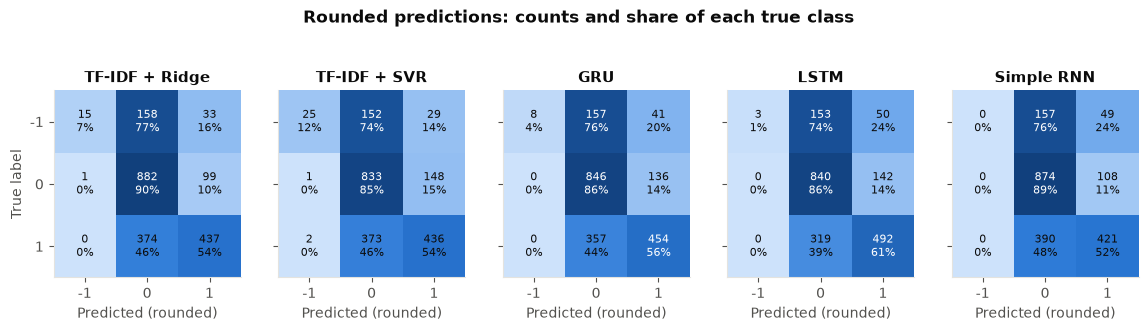

,accuracy,macro F1,recall -1,recall 0,recall 1
approach,,,,,
TF-IDF + Ridge,0.667,0.502,0.073,0.898,0.539
TF-IDF + SVR,0.647,0.513,0.121,0.848,0.538
GRU,0.654,0.476,0.039,0.862,0.560
LSTM,0.668,0.473,0.015,0.855,0.607
Simple RNN,0.648,0.445,0.000,0.890,0.519


In [6]:
def to_class(pred):
    return np.clip(np.rint(pred), -1, 1)


LABELS = [-1, 0, 1]
fig, axes = plt.subplots(1, len(MODELS), figsize=(14, 3.2), sharey=True)
class_rows = []
for ax, key in zip(axes, comparison.index):
    cm = confusion_matrix(y, to_class(P[key].to_numpy()), labels=LABELS)
    share = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(share, cmap=SEQUENTIAL, vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i, j]}\n{share[i, j]:.0%}", ha="center", va="center", fontsize=8,
                    color="white" if share[i, j] > 0.55 else INK)
    ax.set_xticks(range(3), ["-1", "0", "1"])
    ax.set_yticks(range(3), ["-1", "0", "1"])
    ax.grid(False)
    ax.set(title=MODELS[key], xlabel="Predicted (rounded)")
    recall = share.diagonal()
    class_rows.append({"approach": MODELS[key], "accuracy": np.trace(cm) / cm.sum(),
                       "macro F1": f1_score(y, to_class(P[key].to_numpy()), labels=LABELS, average="macro"),
                       "recall -1": recall[0], "recall 0": recall[1], "recall 1": recall[2]})
axes[0].set_ylabel("True label")
fig.suptitle("Rounded predictions: counts and share of each true class", x=0.5, y=1.04, fontweight="bold")
fig.savefig(common.FIGURES_DIR / "comparison_confusion_matrices.png")
plt.show()
display(pd.DataFrame(class_rows).set_index("approach").round(3))

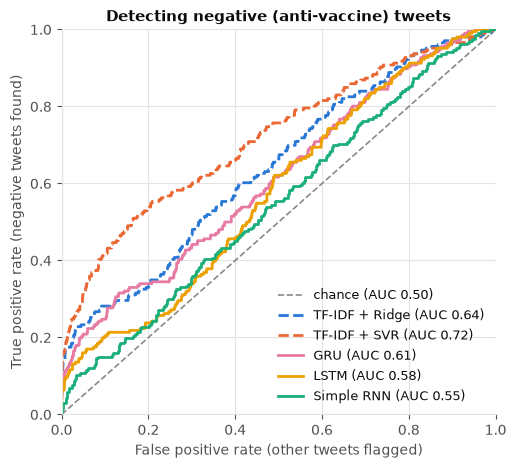

,AUC negative vs rest,AUC negative vs positive,negatives found at 10% false alarms
approach,,,
TF-IDF + Ridge,0.641,0.798,0.282
TF-IDF + SVR,0.716,0.808,0.417
GRU,0.614,0.766,0.248
LSTM,0.579,0.763,0.204
Simple RNN,0.550,0.726,0.150


In [7]:
negative = y == -1
not_neutral = y != 0
fig, ax = plt.subplots(figsize=(5.6, 5))
ax.plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1.2, label="chance (AUC 0.50)")
auc_rows = []
for key in comparison.index:
    score = -P[key].to_numpy()  # lower prediction = more likely anti-vaccine
    fpr, tpr, _ = roc_curve(negative, score)
    auc = roc_auc_score(negative, score)
    auc_rows.append({"approach": MODELS[key], "AUC negative vs rest": auc,
                     "AUC negative vs positive": roc_auc_score(negative[not_neutral], score[not_neutral]),
                     "negatives found at 10% false alarms": np.interp(0.10, fpr, tpr)})
    ax.plot(fpr, tpr, color=SERIES[key], linestyle="--" if FAMILY[key] != "recurrent" else "-",
            label=f"{MODELS[key]} (AUC {auc:.2f})")
ax.set(xlabel="False positive rate (other tweets flagged)", ylabel="True positive rate (negative tweets found)",
       title="Detecting negative (anti-vaccine) tweets", xlim=(0, 1), ylim=(0, 1))
ax.legend(frameon=False, loc="lower right", fontsize=9)
fig.savefig(common.FIGURES_DIR / "comparison_roc_negative.png")
plt.show()
auc_table = pd.DataFrame(auc_rows).set_index("approach")
display(auc_table.round(3))

**What the two views add.**

- Read as classes, every model behaves almost like a neutral-or-positive classifier. It finds between 0% (Simple RNN) and 12% (SVR) of negative tweets and predicts most of them as neutral (74% to 77%), while it gets 85% to 90% of neutral tweets right. Macro F1 runs from 0.445 (Simple RNN) to 0.513 (SVR).
- The ROC view ranks the models differently from RMSE. SVR is the best detector of anti-vaccine tweets (AUC 0.72 against all other tweets); at a 10% false-alarm rate it finds 42% of them, against 28% for Ridge, 25% for the GRU, 20% for the LSTM and 15% for the Simple RNN, whose AUC of 0.55 is barely above chance.
- Every model separates negative from positive tweets much better (AUC 0.73 to 0.81) than from everything else (0.55 to 0.72): the models partly learn which tweets criticise rather than praise vaccines, but place most anti-vaccine tweets among the neutral ones.
- For a monitoring use, where the goal is to find anti-vaccine posts, SVR would be the better tool even though Ridge has the lowest RMSE, and even SVR would miss more than half of them at a manageable false-alarm rate.

## 5. Where the approaches differ (step 47)

The table below scores every model on groups of tweets defined by properties the EDA in notebook 01 flagged: the true label, annotator agreement, negation, tweet length after the shared cleaning, and the share of words the models never learned (tokens seen fewer than twice in the training split, which the recurrent models map to `[UNK]`). The negative class is also split by agreement, because notebook 01 found that every tweet whose three annotators all disagreed (agreement 1/3) is labelled -1.

In [8]:
train_tokens = prepare_series(train_df["safe_text"]).str.split()
counts = Counter(token for tokens in train_tokens for token in tokens)
known = {token for token, n in counts.items() if n >= 2}  # the recurrent models' vocabulary (MIN_COUNT = 2)

val_tokens = prepare_series(val_df["safe_text"]).str.split()
T = pd.DataFrame({
    "label": y,
    "agreement": val_df["agreement"].round(3).to_numpy(),
    "negation": val_df["safe_text"].str.lower().str.contains(NEGATION, regex=True).to_numpy(),
    "tokens": val_tokens.str.len().to_numpy(),
    "unknown share": np.array([np.mean([t not in known for t in tokens]) for tokens in val_tokens]),
    "url": val_df["safe_text"].str.contains("<url>", regex=False).to_numpy(),
    "hashtag": val_df["safe_text"].str.contains("#", regex=False).to_numpy(),
}, index=P.index)
T["length"] = pd.qcut(T["tokens"], 3)
T["unknown words"] = pd.cut(T["unknown share"], [-0.01, 0, 0.10, 1], labels=["none", "up to 10%", "over 10%"])
AGREE = {0.333: "1/3", 0.667: "2/3", 1.0: "3/3"}

groups = {
    ("true label", "negative (-1)"): T["label"] == -1,
    ("true label", "neutral (0)"): T["label"] == 0,
    ("true label", "positive (1)"): T["label"] == 1,
    **{("negative tweets by agreement", AGREE[a]): (T["label"] == -1) & (T["agreement"] == a) for a in AGREE},
    ("negation", "contains a negation"): T["negation"],
    ("negation", "no negation"): ~T["negation"],
    **{("tokens after cleaning", f"{int(b.left) + 1} to {int(b.right)}"): T["length"] == b for b in T["length"].cat.categories},
    **{("unknown words", level): T["unknown words"] == level for level in T["unknown words"].cat.categories},
}
by_group = pd.DataFrame(
    {("", "tweets"): {g: int(mask.sum()) for g, mask in groups.items()},
     **{("RMSE", MODELS[k]): {g: common.rmse(y[mask.to_numpy()], P[k].to_numpy()[mask.to_numpy()]) for g, mask in groups.items()}
        for k in comparison.index}}
)
by_group.index = pd.MultiIndex.from_tuples(by_group.index)
display(by_group.round(3))
negation_gap = (by_group.loc[("negation", "contains a negation"), "RMSE"] - by_group.loc[("negation", "no negation"), "RMSE"])
print("Extra RMSE on tweets with a negation:", ", ".join(f"{name} {gap:.3f}" for name, gap in negation_gap.items()))

RMSE  \
                                                 tweets TF-IDF + Ridge   
true label                   negative (-1)          206          1.198   
                             neutral (0)            982          0.299   
                             positive (1)           811          0.555   
negative tweets by agreement 1/3                     47          1.290   
                             2/3                     83          1.215   
                             3/3                     76          1.117   
negation                     contains a negation    507          0.609   
                             no negation           1492          0.546   
tokens after cleaning        2 to 15                724          0.548   
                             16 to 20               729          0.551   
                             21 to 36               546          0.597   
unknown words                none                   691          0.538   
                             up to 10%              655          0.594   
                             over 10%               653          0.556   

                                                                             \
                                                 TF-IDF + SVR    GRU   LSTM   
true label                   negative (-1)              1.166  1.261  1.315   
                             neutral (0)                0.352  0.329  0.333   
                             positive (1)               0.563  0.534  0.500   
negative tweets by agreement 1/3                        1.302  1.347  1.394   
                             2/3                        1.191  1.264  1.307   
                             3/3                        1.042  1.200  1.272   
negation                     contains a negation        0.619  0.624  0.627   
                             no negation                0.558  0.560  0.560   
tokens after cleaning        2 to 15                    0.556  0.548  0.553   
                             16 to 20                   0.564  0.575  0.576   
                             21 to 36                   0.609  0.615  0.612   
unknown words                none                       0.554  0.550  0.555   
                             up to 10%                  0.601  0.610  0.609   
                             over 10%                   0.566  0.570  0.569   

                                                             
                                                 Simple RNN  
true label                   negative (-1)            1.323  
                             neutral (0)              0.306  
                             positive (1)             0.536  
negative tweets by agreement 1/3                      1.379  
                             2/3                      1.307  
                             3/3                      1.305  
negation                     contains a negation      0.636  
                             no negation              0.567  
tokens after cleaning        2 to 15                  0.560  
                             16 to 20                 0.582  
                             21 to 36                 0.623  
unknown words                none                     0.571  
                             up to 10%                0.620  
                             over 10%                 0.564

Extra RMSE on tweets with a negation: TF-IDF + Ridge 0.063, TF-IDF + SVR 0.061, GRU 0.065, LSTM 0.066, Simple RNN 0.068


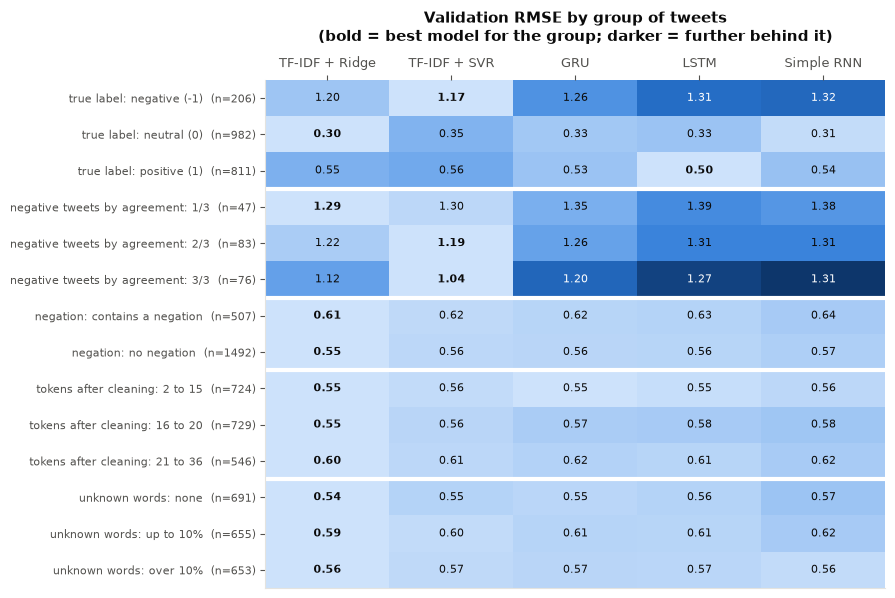

In [9]:
values = by_group["RMSE"].to_numpy()
gap = values - values.min(axis=1, keepdims=True)  # 0 = the best model for that group of tweets
fig, ax = plt.subplots(figsize=(8, 6.6))
ax.imshow(gap, cmap=SEQUENTIAL, aspect="auto", vmin=0, vmax=gap.max())
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if gap[i, j] > 0.55 * gap.max() else INK,
                fontweight="bold" if gap[i, j] == 0 else "normal")
labels = [f"{group}: {name}  (n={n})" for (group, name), n in zip(by_group.index, by_group[("", "tweets")])]
ax.set_yticks(range(len(labels)), labels, fontsize=8)
ax.set_xticks(range(values.shape[1]), by_group["RMSE"].columns, fontsize=9)
ax.xaxis.tick_top()
ax.grid(False)
for boundary in np.flatnonzero(by_group.index.get_level_values(0)[1:] != by_group.index.get_level_values(0)[:-1]):
    ax.axhline(boundary + 0.5, color="white", linewidth=3)
ax.set_title("Validation RMSE by group of tweets\n(bold = best model for the group; darker = further behind it)", pad=28)
fig.savefig(common.FIGURES_DIR / "comparison_rmse_by_group.png")
plt.show()

**What the groups show.**

- The negative class dominates the error for every model (RMSE 1.17 to 1.32, against 0.30 to 0.35 for neutral and 0.50 to 0.56 for positive tweets), so the overall ranking is largely a ranking on 206 negative tweets.
- The two families fail in different places. The TF-IDF models are best on negative tweets (SVR 1.17, Ridge 1.20, against 1.26 to 1.32 for the recurrent models) and Ridge is best on neutral ones, while the recurrent models do best on positive tweets (LSTM 0.50). One reading is that embeddings learned from 8,001 tweets capture the frequent pro-vaccine wording, while word and word-pair counts keep more of the signal carried by rarer anti-vaccine phrases.
- Error falls as annotator agreement rises, for every model: SVR goes from 1.30 on the 47 negative tweets where all three annotators disagreed to 1.04 where all agreed. Label uncertainty explains part of the negative-class error, yet unanimous negative tweets still have RMSE above 1 for every model.
- A negation raises the error by about the same amount for every model (0.061 to 0.068), bag-of-words and recurrent alike. Reading the tokens in order did not make the recurrent models better at negation on this data.
- Longer tweets are harder for all five, and the recurrent models do not catch up with Ridge as tweets get longer (on the longest third, Ridge 0.60 against 0.61 to 0.62). With at most 36 tokens after cleaning there is little long-range order to exploit, unlike the longer sentences where Yin et al. (2017) saw the GRU's advantage grow.
- Unknown words show no steady effect: tweets with none are easiest, but those with more than 10% unknown tokens are easier than those with up to 10%. Rare vocabulary is not what drives the errors.

## 6. Tweets that are hard for every model (steps 48 and 49)

A tweet counts as badly wrong for a model when the prediction is more than one class step from the true label (absolute error above 1), for example a negative tweet predicted above 0. The first view counts, for every tweet, how many of the five models get it badly wrong; the tables then compare the models' largest errors and how closely their errors move together.

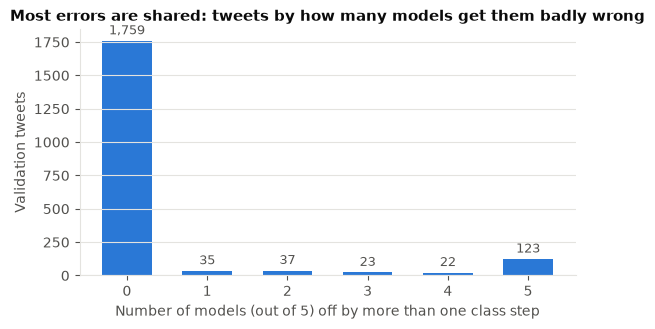

Badly wrong for all five: 123 tweets; for none: 1,759; for one to four models: 117
Tweets shared between each pair's 50 largest errors:


,TF-IDF + Ridge,TF-IDF + SVR,GRU,LSTM,Simple RNN
TF-IDF + Ridge,50,44,31,34,26
TF-IDF + SVR,44,50,28,31,26
GRU,31,28,50,45,33
LSTM,34,31,45,50,35
Simple RNN,26,26,33,35,50


Correlation of the models' errors (prediction minus true label):


,TF-IDF + Ridge,TF-IDF + SVR,GRU,LSTM,Simple RNN
TF-IDF + Ridge,1.000,0.981,0.949,0.953,0.934
TF-IDF + SVR,0.981,1.000,0.936,0.928,0.914
GRU,0.949,0.936,1.000,0.986,0.957
LSTM,0.953,0.928,0.986,1.000,0.973
Simple RNN,0.934,0.914,0.957,0.973,1.000


In [10]:
abs_err = P.sub(y, axis=0).abs()
n_bad = (abs_err > 1).sum(axis=1)
dist = n_bad.value_counts().reindex(range(6), fill_value=0)

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.bar(dist.index, dist.values, color=BLUE, width=0.62)
for x, v in zip(dist.index, dist.values):
    ax.text(x, v + dist.max() * 0.015, f"{v:,}", ha="center", va="bottom", color=INK_2, fontsize=9)
ax.set_xticks(range(6))
ax.grid(axis="x", visible=False)
ax.set(xlabel="Number of models (out of 5) off by more than one class step", ylabel="Validation tweets",
       title="Most errors are shared: tweets by how many models get them badly wrong")
fig.savefig(common.FIGURES_DIR / "comparison_error_overlap.png")
plt.show()
print(f"Badly wrong for all five: {dist[5]} tweets; for none: {dist[0]:,}; for one to four models: {dist[1:5].sum()}")

top50 = {k: set(abs_err[k].nlargest(50).index) for k in comparison.index}
overlap = pd.DataFrame({MODELS[a]: {MODELS[b]: len(top50[a] & top50[b]) for b in comparison.index} for a in comparison.index})
print("Tweets shared between each pair's 50 largest errors:")
display(overlap)
print("Correlation of the models' errors (prediction minus true label):")
display(P.sub(y, axis=0)[list(comparison.index)].rename(columns=MODELS).corr().round(3))

**The same tweets are hard for all five.** Only 117 tweets are badly wrong for between one and four models; 123 are badly wrong for all five and 1,759 for none. The two TF-IDF models share 44 of their 50 largest errors and the GRU and LSTM share 45, while pairs across the two families share 26 to 34. The errors themselves are strongly correlated (0.91 to 0.99).

**Would combining the models help?** If the models made different mistakes, averaging their predictions would cancel some of them. The averages below use equal weights and fit nothing on the validation set, so they are evidence about how complementary the errors are, not new tuned models.

In [11]:
averages = {
    "all five": list(MODELS),
    "the two TF-IDF baselines": ["ridge", "svr"],
    "the three recurrent models": ["rnn", "lstm", "gru"],
    f"{MODELS[BEST]} + GRU": [BEST, "gru"],
}
display(pd.DataFrame({
    "val RMSE": {name: common.rmse(y, P[keys].mean(axis=1)) for name, keys in averages.items()},
    "best single member": {name: min(common.rmse(y, P[k]) for k in keys) for name, keys in averages.items()},
}).round(4))

,val RMSE,best single member
all five,0.5638,0.5628
the two TF-IDF baselines,0.5654,0.5628
the three recurrent models,0.5745,0.5769
TF-IDF + Ridge + GRU,0.5624,0.5628


Averaging barely helps, as the correlations predict. The average of all five (0.5638) is worse than Ridge alone, and Ridge + GRU improves on Ridge by only 0.0004. Only the three recurrent models gain from averaging (0.5745 against the GRU's 0.5769), which is what averaging out seed noise would produce. A better score needs new information about the tweets, not another combination of these five models.

**What the shared hard cases look like.** The next table compares the tweets that all five models get badly wrong with the rest of the validation set on the properties from section 5, then prints the twelve hard tweets with the largest average error. Only these few are printed.

In [12]:
hard = n_bad == 5
profile = pd.DataFrame({
    group: {
        "tweets": int(mask.sum()),
        "negative (-1)": (T.loc[mask, "label"] == -1).mean(),
        "positive (1)": (T.loc[mask, "label"] == 1).mean(),
        "agreement 1/3": (T.loc[mask, "agreement"] == 0.333).mean(),
        "contains a negation": T.loc[mask, "negation"].mean(),
        "contains a link": T.loc[mask, "url"].mean(),
        "contains a hashtag": T.loc[mask, "hashtag"].mean(),
        "median tokens": T.loc[mask, "tokens"].median(),
        "mean unknown-word share": T.loc[mask, "unknown share"].mean(),
    }
    for group, mask in {"hard for all five": hard, "all other tweets": ~hard}.items()
})
display(profile.round(3))
negatives, low_agreement = T["label"] == -1, T["agreement"] == 0.333
print(f"{int((hard & negatives).sum())} of {int(negatives.sum())} negative validation tweets "
      f"({(hard & negatives).sum() / negatives.sum():.0%}) are badly wrong for all five models")
print(f"{int((hard & low_agreement).sum())} of {int(low_agreement.sum())} tweets with agreement 1/3 are badly wrong for all five")

sample = (val_df.set_index("tweet_id").loc[hard[hard].index, ["label", "agreement", "safe_text"]]
          .assign(mean_prediction=P.loc[hard, list(MODELS)].mean(axis=1), mean_abs_error=abs_err.loc[hard].mean(axis=1))
          .nlargest(12, "mean_abs_error"))
with pd.option_context("display.max_colwidth", 150):
    display(sample[["label", "mean_prediction", "agreement", "safe_text"]].round(3))

,hard for all five,all other tweets
tweets,123.000,1876.000
negative (-1),0.992,0.045
positive (1),0.008,0.432
agreement 1/3,0.301,0.005
contains a negation,0.333,0.248
contains a link,0.374,0.429
contains a hashtag,0.252,0.261
median tokens,19.000,18.000
mean unknown-word share,0.075,0.085


122 of 206 negative validation tweets (59%) are badly wrong for all five models
37 of 47 tweets with agreement 1/3 are badly wrong for all five


,label,mean_prediction,agreement,safe_text
tweet_id,,,,
A3W81QVQ,-1.0,0.907,0.667,Anti-Vaccine Mom Would Rather Lose Baby Than Vaccinate - via <user> <url>
AP8D8KXB,-1.0,0.884,0.333,<user> maybe its our natural desire to immunize those we love. Like giving your kids chicken pocks.
QK5Y1ZWX,-1.0,0.848,0.667,Don't let the schools tell you to vaccinate your children
M4IVFSMS,-1.0,0.823,1.000,"#whatcausesautism VACCINES, DO NOT VACCINATE YOUR CHILD"
DVMK1WEI,-1.0,0.771,0.667,"""<user> RT <user> RT <user> For God's sake. Vaccinate your damn kids."" Even tho its the main cause of austism?"
4Y75EP2E,-1.0,0.765,0.667,<user> <user> there are plenty of NON CHRISTIANS that won't let their kids get vaccinated. Inc Orthodox Jews. Parents of Autism
5KDOWBMS,-1.0,0.750,1.000,<user> don't vaccinate your children
XRTV4HU8,-1.0,0.688,1.000,I don't want kids cause I'm gonna give my kids autism cause of the vaccinations us 90s kids had as a kid
S1ZZQQHD,-1.0,0.661,0.667,Christie: Parents Should Have 'Some Measure Of Choice' On Vaccinating Their Children <url> via <user>


**What the hard tweets have in common.** 122 of the 123 are negative tweets, so 59% of all negative validation tweets are badly wrong for every model. They are also where the annotators disagreed: 30% have agreement 1/3, against 0.5% of the other tweets, and 37 of the 47 tweets with agreement 1/3 are in this group. Links, hashtags, length and unknown words look much the same as in the rest of the data, so surface form does not mark them out. In the twelve printed above, four patterns recur, often together:

- **Reporting rather than arguing.** Headlines about anti-vaccine parents or politicians ("Anti-Vaccine Mom Would Rather Lose Baby Than Vaccinate", "'No jab, no pay' laws could send anti-vax parents underground") are labelled negative although they are worded as news. The label follows the stance being reported, which a model reading only the words cannot see.
- **Negated pro-vaccine phrases.** "don't vaccinate your children" and "DO NOT VACCINATE YOUR CHILD" reuse the words of pro-vaccine tweets, and all five models predict them on the positive side, including Ridge with its word pairs.
- **Sarcasm.** One tweet presents immunising children as "our natural desire" and compares it to "giving your kids chicken pocks"; another quotes a pro-vaccine tweet and adds that vaccines are "the main cause of austism".
- **Stance carried by a claim or a complaint.** Tweets linking vaccines to autism, or saying that a state bullies parents into immunisation, contain few sentiment words; the stance lies in what is claimed.

Spelling variation appears inside these cases ("austism", "chicken pocks") but is not the main difficulty.

**Rarer patterns the brief asks about.** Code-switching and spelling variation were checked directly rather than assumed. Tweets containing accented Latin letters (a simple marker of Spanish, Portuguese or French words in this English-language data) and tweets with a letter repeated three or more times in the raw text (spelling variation such as "sooo", which the shared cleaning shortens to two letters) are counted and scored.

In [13]:
def has(pattern):
    return val_df["safe_text"].map(lambda text: re.search(pattern, text) is not None).to_numpy()


patterns = {
    "accented Latin letters (possible code-switching)": has(r"[À-ɏ]"),
    "elongated spelling (a letter repeated 3+ times)": has(r"([A-Za-z])\1{2,}"),
}
display(pd.DataFrame({
    name: {"tweets": int(mask.sum()), **{MODELS[k]: common.rmse(y[mask], P[k].to_numpy()[mask]) for k in comparison.index}}
    for name, mask in patterns.items()
}).T.round(3))
with pd.option_context("display.max_colwidth", 120):
    display(val_df.loc[patterns["accented Latin letters (possible code-switching)"], ["label", "safe_text"]])

,tweets,TF-IDF + Ridge,TF-IDF + SVR,GRU,LSTM,Simple RNN
accented Latin letters (possible code-switching),3.0,0.424,0.404,0.479,0.530,0.562
elongated spelling (a letter repeated 3+ times),21.0,0.464,0.482,0.465,0.443,0.452


,label,safe_text
97,0.0,"<user> en lo q aprende español, le voy preparando el ambiente, #MMR"
118,1.0,"Suffer the Children: The Vaccination ""Debate"" Gets the Measles <url> /cì#mm"
1909,1.0,Vaccination day! Now my babies are safe. 🐴🐎💉\nDia de vacinação! Agora meus bebês estão a… <url>


**Code-switching and spelling variation are rare in this data.** Only 3 validation tweets contain accented Latin letters (Spanish and Portuguese), and 21 have elongated spellings. Both groups score better than each model's overall RMSE, but they are too small to conclude more than that neither is a main source of error here; the shared cleaning already shortens elongated words.

## 7. Experiments behind each approach

`common.merge_experiment_logs()` rebuilt `results/experiment_results.csv` from every model's log in section 3. The summary below shows how many runs each owner logged and how far the saved model sits from the best single run, a reminder that each saved model was chosen by its own notebook's rule (for the recurrent models, the simplest configuration within seed noise of the best).

In [14]:
summary = logs.groupby("model").agg(owner=("owner", "first"), runs=("run_id", "size"),
                                    best_run_rmse=("val_rmse", "min"), worst_run_rmse=("val_rmse", "max"))
summary["saved model RMSE"] = [common.rmse(y, P[k]) for k in summary.index]
summary = summary.loc[list(comparison.index)].rename(index=MODELS)
display(summary.round(4))

out = comparison.drop(columns=["family"]).join(pd.DataFrame(class_rows).set_index("approach"), on="approach")
out = out.join(auc_table, on="approach").set_index("approach")
out.to_csv(common.RESULTS_DIR / "model_comparison.csv", float_format="%.4f")
print("Saved results/model_comparison.csv")

,owner,runs,best_run_rmse,worst_run_rmse,saved model RMSE
model,,,,,
TF-IDF + Ridge,Adossi Fred William,7,0.5628,0.5791,0.5628
TF-IDF + SVR,Adossi Fred William,8,0.5740,0.5991,0.5740
GRU,Serein Byiringiro Shima,15,0.5731,0.5905,0.5769
LSTM,Parfait Christian Henry UHIRIWE,13,0.5704,0.5878,0.5780
Simple RNN,Honourgod Kilechukwu Levison,15,0.5855,0.6123,0.5855


Saved results/model_comparison.csv


Each recurrent notebook saved the seed-42 run of the configuration its own rule chose, not its luckiest seed: the LSTM's best single run (0.5704) and the GRU's (0.5731) came from other seeds of their final configurations. The saved scores are therefore not cherry-picked, although each still benefits from choosing among many runs on the same validation set.

## 8. Conclusions, limitations and future work

### What the comparison shows

The research question asks how effectively sequential models address this problem. On this data the three recurrent networks clearly beat always predicting the mean (0.5769 to 0.5855 against 0.6459), and gating helps: the GRU and LSTM beat the Simple RNN in at least 98% of paired resamples. None of them beats TF-IDF + Ridge with word pairs, though, and SVR is the best at finding anti-vaccine tweets. The largest source of error, the negative class, is shared by all five approaches and traces back to the data: disputed labels, stance that is reported rather than expressed, sarcasm, and claims that need knowledge from outside the tweet.

### Limitations (step 50)

- **Data.** 10,000 labelled tweets, 8,001 of them for training, with only about 10% negative. Every tweet whose three annotators all disagreed is labelled -1 (notebook 01), so part of the negative class records disagreement rather than a clear stance; 37 of the 47 such validation tweets are badly wrong for every model. The tweets are in English, with almost no code-switching.
- **Task framing.** Three ordered classes are treated as a score. The squared-error loss pulls uncertain predictions towards the middle, which is why most negative tweets are predicted neutral.
- **Models.** Word vectors are learned from 8,001 tweets, each recurrent model has one layer, and no model uses pretrained representations or class weighting.
- **Experiments.** Each owner tuned one setting at a time with their own selection rule, and the validation set also chose the stopping epoch and the configuration, so every reported RMSE is somewhat optimistic. The recurrent models were checked on three to six seeds.
- **Evaluation.** One split and no separate test set. The bootstrap intervals describe resampling of these 1,999 tweets, not tweets from another period or platform. RMSE is not comparable with the F1 scores published for vaccine-tweet classification.
- **Responsible use.** The class these models miss is the one a public-health user would care about most: used for monitoring, they would under-count anti-vaccine content and could give false reassurance. The labels are three crowd annotators' readings (Müller & Salathé, 2019), and the tweets are public posts by real people, which is why this repository never publishes their text.

### Future work (step 51), each tied to a result above

1. **Handle disputed labels explicitly.** Report results separately for tweets with 2/3 or 3/3 agreement, or model disagreement as its own outcome, instead of scoring agreement-1/3 tweets as confident negatives (sections 5 and 6). Weighting training tweets by agreement did not help the LSTM (notebook 03, run lstm-06), so the fix lies in how these labels are defined and evaluated.
2. **Train for the negative class.** Use a class-weighted loss or a classification objective judged by macro F1 or AUC, since the regression objective leaves negative recall at 0% to 12% (section 4).
3. **Bring in outside knowledge.** Pretrained embeddings or a domain-adapted transformer such as COVID-Twitter-BERT (Müller et al., 2023); pretrained representations improved vaccine-tweet models in Zhang et al. (2020). The shared hard cases need context that 8,001 training tweets cannot supply, and averaging our five models barely helped (section 6).
4. **Clip predictions to [-1, 1].** A small gain for every model at no cost (section 3).
5. **Evaluate more robustly.** Repeated or cross-validated splits would settle rankings as close as GRU against LSTM (65.6% of resamples).

## Notes and sources

### References

- Chai, T., & Draxler, R. R. (2014). Root mean square error (RMSE) or mean absolute error (MAE)? – Arguments against avoiding RMSE in the literature. *Geoscientific Model Development, 7*(3), 1247–1250. https://doi.org/10.5194/gmd-7-1247-2014
- Dror, R., Baumer, G., Shlomov, S., & Reichart, R. (2018). The hitchhiker's guide to testing statistical significance in natural language processing. In *Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)* (pp. 1383–1392). Association for Computational Linguistics. https://doi.org/10.18653/v1/P18-1128
- Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters, 27*(8), 861–874. https://doi.org/10.1016/j.patrec.2005.10.010
- Koehn, P. (2004). Statistical significance tests for machine translation evaluation. In *Proceedings of the 2004 Conference on Empirical Methods in Natural Language Processing* (pp. 388–395). Association for Computational Linguistics. https://aclanthology.org/W04-3250/
- Müller, M., Salathé, M., & Kummervold, P. E. (2023). COVID-Twitter-BERT: A natural language processing model to analyse COVID-19 content on Twitter. *Frontiers in Artificial Intelligence, 6*, Article 1023281. https://doi.org/10.3389/frai.2023.1023281
- Müller, M. M., & Salathé, M. (2019). Crowdbreaks: Tracking health trends using public social media data and crowdsourcing. *Frontiers in Public Health, 7*, Article 81. https://doi.org/10.3389/fpubh.2019.00081
- Naseem, U., Khushi, M., Kim, J., & Dunn, A. G. (2021). Classifying vaccine sentiment tweets by modelling domain-specific representation and commonsense knowledge into context-aware attentive GRU. In *2021 International Joint Conference on Neural Networks (IJCNN)* (pp. 1–8). IEEE. https://doi.org/10.1109/IJCNN52387.2021.9533454
- Reimers, N., & Gurevych, I. (2017). Reporting score distributions makes a difference: Performance study of LSTM-networks for sequence tagging. In *Proceedings of the 2017 Conference on Empirical Methods in Natural Language Processing* (pp. 338–348). Association for Computational Linguistics. https://doi.org/10.18653/v1/D17-1035
- Willmott, C. J., & Matsuura, K. (2005). Advantages of the mean absolute error (MAE) over the root mean square error (RMSE) in assessing average model performance. *Climate Research, 30*(1), 79–82. https://doi.org/10.3354/cr030079
- Yin, W., Kann, K., Yu, M., & Schütze, H. (2017). *Comparative study of CNN and RNN for natural language processing* (arXiv:1702.01923). arXiv. https://doi.org/10.48550/arXiv.1702.01923
- Zhang, L., Fan, H., Peng, C., Rao, G., & Cong, Q. (2020). Sentiment analysis methods for HPV vaccines related tweets based on transfer learning. *Healthcare, 8*(3), Article 307. https://doi.org/10.3390/healthcare8030307
- Zindi. (2020). *To vaccinate or not to vaccinate: It's not a question* [Data set]. https://zindi.africa/competitions/to-vaccinate-or-not-to-vaccinate